# Notebook 1 · Why LangChain Exists

### The context, the history, and the problem it actually solves

This is the on-ramp for a six-notebook series. We do not touch the framework yet. First we earn the right to use it: we look at why language is hard for machines, what a raw model call can and cannot do, and the pile of plumbing you would write by hand without a framework. Only then does LangChain make sense.

**The series (a connected spine):**

| # | Notebook | You will be able to |
|---|----------|---------------------|
| 1 | Why LangChain exists | explain the problem before reaching for the tool (this notebook) |
| 2 | Essentials: how it works | run a real agent loop with real message objects |
| 3 | Basic LangChain | give an agent tools and watch it choose |
| 4 | Intermediate LangChain | add memory, structured output, and guardrails |
| 5 | Advanced LangChain | control the graph, split into multiple agents |
| 6 | LangChain vs Strands | do the same operations in both frameworks |

**Anchor scenario across the whole series:** TravelMind, an airline support agent. One passenger keeps coming back: PNR `JX48Q2`, surname Rao, Gold tier, segment BLR to DEL cancelled. Same problem solved with more and more capability, so you feel each layer being added.

### How to read every notebook in this series

Each code cell is wrapped in the same rhythm, so the only thing you track is the new idea:

```text
[ before the cell ]  a diagram of what is about to happen,
                     plus the functions and concepts it uses
[ the code cell   ]  small, runnable, one idea at a time
[ after the cell  ]  what actually happened, drawn out,
                     plus a question worth sitting with
```

**Callout legend** (used throughout):

> **What runs next** the plan for the cell below.
> **Python construct** a plain Python feature worth naming.
> **LLM concept** an idea specific to language models.
> **Language concept** an idea from how language itself works.
> **What just happened** the flow, after the fact.
> **Skeptic's corner** the objection a sharp person would raise.
> **Gotcha** the thing that bites people in production.

**Dependencies for this notebook:** only `matplotlib`. No API keys, no cloud. Everything here runs on your laptop.

```bash
pip install matplotlib
```

---
## 1. Why is language hard for machines?

A programming language is designed to have exactly one meaning. Natural language is the opposite: it is compressed, context-dependent, and endlessly productive. The same words carry different meaning depending on who says them and when.

Three properties make it hard:

| Property | Plain meaning | Example |
|----------|---------------|---------|
| Ambiguity | one string, several readings | "book the flight" vs "read the book" |
| Context dependence | meaning needs the surroundings | "cancel it" means nothing without the "it" |
| Productivity | infinite valid sentences | you have never seen this exact sentence before |

The field spent decades climbing from hand-written rules to systems that learn meaning from data:

```mermaid
flowchart LR
    A[Hand-written rules if-then grammars] --> B[Statistical NLP count word patterns]
    B --> C[Word embeddings meaning as vectors]
    C --> D[Transformers attention over context]
    D --> E[Large language models predict the next token]
```

> **Skeptic's corner** if models learned language from data, why do they still get simple things wrong? Because prediction is not understanding. Keep that tension. It explains most agent failures later in the series.

### 1a. A bot built on keywords, and why it snaps

Before neural models, a support bot was a pile of keyword rules. It works for the sentence you imagined and breaks on the next one.

```mermaid
flowchart LR
    U[User text] --> K{contains a keyword?}
    K -- cancel --> R1[route: cancellation]
    K -- book --> R2[route: booking]
    K -- none --> R3[fallback: I did not understand]
```

> **What runs next** a keyword intent bot with three rules, tested on four messages.
> **Python construct** a function returning a label, simple membership tests with `in`.
> **Language concept** polysemy: one word, many meanings. The word "book" will betray us.

In [ ]:
def keyword_intent(text: str) -> str:
    t = text.lower()
    if "cancel" in t:
        return "CANCELLATION"
    if "book" in t:
        return "BOOKING"
    return "FALLBACK"

tests = [
    "My flight got cancelled, help",       # clearly cancellation
    "I want to book a seat",               # clearly booking
    "Can I bring a book on the flight?",   # trap: 'book' is a noun here
    "The delay ruined my day",             # no keyword at all
]
for t in tests:
    print(f"{keyword_intent(t):13} <-  {t}")

CANCELLATION  <-  My flight got cancelled, help
BOOKING       <-  I want to book a seat
BOOKING       <-  Can I bring a book on the flight?
FALLBACK      <-  The delay ruined my day


> **What just happened** rule three misfires. "Can I bring a book on the flight?" is tagged `BOOKING` because the string `book` appears, even though the passenger is asking about hand luggage. Rule four falls through to `FALLBACK` because frustration has no keyword.

Keyword systems do not model meaning, they match surface strings. Every new phrasing needs a new rule, and the rules fight each other. This is the wall that pushed the field toward models that learn from examples instead of lists.

```mermaid
flowchart LR
    subgraph Fragile
      K[keyword rules] --> P[breaks on new phrasing]
    end
    subgraph Learned
      M[model trained on text] --> G[generalises to unseen sentences]
    end
    Fragile -.the leap.-> Learned
```

---
## 2. A model is a next-token predictor

Strip away the mystery. A language model reads a sequence of tokens and predicts the next one, over and over. Chat models wrap that predictor in roles (system, user, assistant) so a conversation has structure.

```mermaid
flowchart LR
    S["tokens so far: the flight is"] --> M[model]
    M --> P["scores over the whole vocabulary cancelled 0.6 · delayed 0.3 · on 0.1"]
    P --> T[pick one: 'cancelled']
    T --> S2["append, then repeat"]
```

To make this concrete, we build a toy predictor from a tiny corpus. It has no attention and no understanding. It only counts which word tends to follow which. That is enough to feel the core loop.

### 2a. A toy next-token model in twelve lines

> **What runs next** count word pairs in a small corpus, then generate text by repeatedly sampling the next word.
> **Python construct** `defaultdict` for counting without key checks, `random.choices` for weighted sampling, a fixed `seed` so your run matches this text.
> **LLM concept** next-token prediction and sampling. Higher randomness is the toy version of temperature.

In [ ]:
import random
from collections import defaultdict
random.seed(7)

corpus = (
    "your flight is cancelled please rebook the passenger "
    "the passenger is gold tier on the cancelled flight "
    "rebook the passenger on the next available flight "
    "the flight to delhi is delayed not cancelled "
    "please confirm the rebooking for the passenger"
).split()

# word -> {following_word: count}
bigrams = defaultdict(lambda: defaultdict(int))
for a, b in zip(corpus, corpus[1:]):
    bigrams[a][b] += 1

def next_token(word: str) -> str:
    following = bigrams[word]
    if not following:
        return random.choice(corpus)
    words = list(following)
    weights = [following[w] for w in words]
    return random.choices(words, weights=weights, k=1)[0]

def generate(start: str, n: int = 8) -> str:
    out = [start]
    for _ in range(n):
        out.append(next_token(out[-1]))
    return " ".join(out)

print(generate("the"))
print(generate("please"))

the passenger the next available flight rebook the cancelled
please rebook the passenger the passenger on the passenger


> **What just happened** the model never learned grammar. It learned that after "the" you often see "passenger" or "flight", and it stitched a plausible sentence from those odds. Real models do the same thing at enormous scale, with attention letting them weigh far-apart words instead of just the previous one.

> **Skeptic's corner** "so a language model is just autocomplete?" Mechanically, next-token prediction, yes. What changes everything is scale and attention: at billions of parameters the model captures syntax, facts, and reasoning patterns as a side effect of predicting well. Autocomplete is the engine, not the ceiling.

### 2b. See the odds the model is sampling from

A model does not pick one word, it produces a distribution over the whole vocabulary and then samples. Let us plot that distribution for a single word in our toy.

> **What runs next** turn the counts after one word into probabilities and draw them as a bar chart.
> **Python construct** normalise counts to sum to one, plot with `matplotlib`.
> **LLM concept** the model output is a probability distribution, not a single answer. Sampling is where variety comes from.

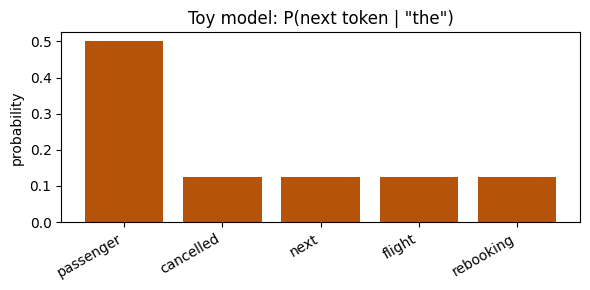

In [ ]:
import matplotlib.pyplot as plt

word = "the"
dist = bigrams[word]
labels = list(dist)
counts = [dist[w] for w in labels]
total = sum(counts)
probs = [c / total for c in counts]

plt.figure(figsize=(6, 3))
plt.bar(labels, probs, color="#B45309")
plt.title(f'Toy model: P(next token | "{word}")')
plt.ylabel("probability")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

> **What just happened** after "the", the toy assigns most of its probability to a couple of words and a little to the rest. A real model does this over a vocabulary of tens of thousands, informed by the entire preceding context, not just one word. Same shape, vastly more inputs.

---
## 3. One model call cannot do the job

A raw chat call is a pure function: messages in, one message out. That is powerful for writing and reasoning, and useless the moment you need a fact the model does not hold or an action in the real world.

```mermaid
flowchart LR
    IN["messages in (system + user)"] --> LLM[chat model]
    LLM --> OUT["one message out (assistant text)"]
```

TravelMind cannot answer "is JX48Q2 cancelled?" from a single call. That fact lives in a booking system, not in the model weights. To be useful, the model has to be allowed to call tools, read the result, and continue. Doing that by hand is the loop below.

### 3a. Hand-roll the agent loop, feel the plumbing

We simulate the model with a scripted stand-in so the run is identical every time and needs no API. The point is not the model, it is the amount of glue code around it.

```mermaid
flowchart TD
    U[user message] --> M[model decides]
    M -->|wants a tool| T[run the tool]
    T --> A[append result to history]
    A --> M
    M -->|no tool needed| F[final answer]
```

> **What runs next** a `run_loop` that manages message history, dispatches tool calls, and stops on a final answer. The model is a scripted function returning fixed steps.
> **Python construct** higher-order functions and closures (`scripted` returns a function that remembers its position), a growing list of message dicts.
> **LLM concept** the agent loop and tool calling: the model asks for a tool by name and arguments, you run it, you feed the result back.
> **Language concept** structured intent extraction: turning free text into a precise call like `lookup_pnr(pnr="JX48Q2")`.

In [ ]:
def run_loop(model, tools, user_msg, max_steps=4):
    messages = [{"role": "user", "content": user_msg}]
    trace = []
    for _ in range(max_steps):
        ai = model(messages)
        trace.append(("model", ai))
        if not ai.get("tool_calls"):
            return ai["content"], trace
        for call in ai["tool_calls"]:
            result = tools[call["name"]](**call["args"])
            messages.append({"role": "tool", "name": call["name"], "content": result})
            trace.append(("tool", {call["name"]: result}))
    return "stopped: hit max steps", trace

def scripted(steps):
    state = {"i": 0}
    def model(_messages):
        step = steps[min(state["i"], len(steps) - 1)]
        state["i"] += 1
        return step
    return model

tools = {
    "lookup_pnr": lambda pnr: f"{pnr}: BLR-DEL cancelled, Rao, Gold tier",
    "search_flights": lambda origin, dest, date: "AI-506 09:40, AI-812 14:15",
}

model = scripted([
    {"tool_calls": [{"name": "lookup_pnr", "args": {"pnr": "JX48Q2"}}]},
    {"tool_calls": [{"name": "search_flights", "args": {"origin": "BLR", "dest": "DEL", "date": "today"}}]},
    {"content": "JX48Q2 BLR-DEL is cancelled. Alternatives today: AI-506 09:40, AI-812 14:15.", "tool_calls": []},
])

answer, trace = run_loop(model, tools, "My flight JX48Q2 is cancelled, what are my options?")
for kind, payload in trace:
    print(f"[{kind:5}] {payload}")
print("\nFINAL:", answer)

[model] {'tool_calls': [{'name': 'lookup_pnr', 'args': {'pnr': 'JX48Q2'}}]}
[tool ] {'lookup_pnr': 'JX48Q2: BLR-DEL cancelled, Rao, Gold tier'}
[model] {'tool_calls': [{'name': 'search_flights', 'args': {'origin': 'BLR', 'dest': 'DEL', 'date': 'today'}}]}
[tool ] {'search_flights': 'AI-506 09:40, AI-812 14:15'}
[model] {'content': 'JX48Q2 BLR-DEL is cancelled. Alternatives today: AI-506 09:40, AI-812 14:15.', 'tool_calls': []}

FINAL: JX48Q2 BLR-DEL is cancelled. Alternatives today: AI-506 09:40, AI-812 14:15.


> **What just happened** to get one helpful answer you personally managed: message history, the stop condition, tool dispatch by name, argument passing, and a max-step guard so a confused model cannot loop forever. That is the plumbing. Now count what this toy still does not handle.

```mermaid
flowchart TD
    Loop[your hand-rolled loop] --> M1[no retries on model errors]
    Loop --> M2[no memory across sessions]
    Loop --> M3[no streaming to the user]
    Loop --> M4[no structured output]
    Loop --> M5[no human approval before risky actions]
    Loop --> M6[no tracing when it goes wrong]
```

Every one of those is real work. You could build them. You would then be maintaining a framework instead of shipping a product. That is the exact gap LangChain fills.

---
## 4. Enter LangChain, briefly

LangChain has a confusing reputation because it changed shape. Knowing the history saves you from copying dead patterns off the internet.

| Era | What it was | Status |
|-----|-------------|--------|
| 2022 to 2023 | "chains": glue for prompts and calls, the `LLMChain` and `SequentialChain` world | legacy, do not learn it first |
| 2023 to 2024 | LCEL, the `|` pipe style, plus early agents | still around, easy to overuse |
| Oct 2025 | LangChain 1.0: rebuilt as an agent framework on the LangGraph runtime | current, this is what we teach |

**The mental model to delete:** "LangChain is a library of chains." **The correct one:** LangChain 1.0 is a thin, stable way to build agents, and underneath it a graph engine (LangGraph) runs the loop you just hand-rolled. The team committed to no breaking changes until a 2.0.

The pieces fit like this:

```mermaid
flowchart TD
    core[langchain-core messages, tool types] --> lc[langchain create_agent, middleware]
    prov[langchain-provider e.g. langchain-aws] --> lc
    lc --> lg[langgraph runs the loop]
    lc --> ls[langsmith tracing and eval]
```

Map the plumbing you wrote by hand to what the framework hands you for free:

| You hand-rolled | LangChain gives you |
|-----------------|---------------------|
| the tool-calling loop | `create_agent` |
| message history plumbing | managed inside the agent state |
| max-step guard, tool dispatch | built in |
| memory across turns | a checkpointer |
| approval before risky actions | human-in-the-loop middleware |
| structured results | a response format |
| visibility when it breaks | LangSmith tracing |

> **Skeptic's corner** do you always need it? No. If your task is one model call with no tools, a framework is pure overhead, and a raw API call is the honest choice. The framework earns its place the moment you have tools, memory, or control flow. We will keep asking this question in every notebook.

---
## 5. The real job: engineering the context

Here is the idea that runs under the entire series. An agent is only as good as what sits in its context window at the moment it thinks. The context window is a fixed budget of tokens, and everything competes for that space:

```mermaid
flowchart LR
    subgraph Context window: a fixed token budget
      SP[system prompt]
      H[conversation history]
      TR[tool results]
      RD[retrieved documents]
    end
    SP --> LLM[model reads all of it, then answers]
    H --> LLM
    TR --> LLM
    RD --> LLM
```

Two things follow. First, more context is not free: it costs money and latency, and it can bury the signal. Second, a long conversation will overflow the budget if you never prune or summarise. Let us watch that happen.

### 5a. Watch context grow until it hits the wall

> **What runs next** simulate a conversation turn by turn, add up a rough token count, and plot it against a pretend budget line.
> **Python construct** accumulate a running total in a loop, plot a threshold with `axhline`.
> **LLM concept** the context budget and why long chats force a strategy: summarise, prune, or retrieve. Numbers below are illustrative, chosen to show the shape, not real model limits.

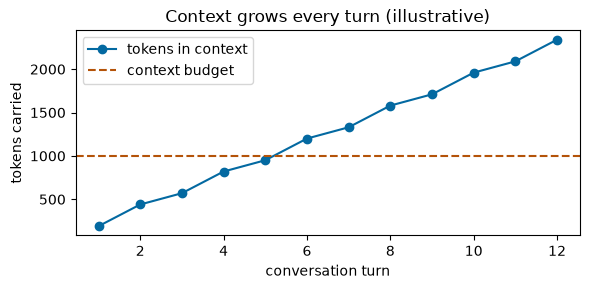

In [1]:
import matplotlib.pyplot as plt

system_prompt = 60      # tokens, charged once
per_user_turn = 40
per_ai_turn = 90
tool_result = 120       # heavy: a booking record dumped into context
budget = 1000           # illustrative budget for the shape of the curve

running = system_prompt
history = []
for turn in range(1, 13):
    running += per_user_turn + per_ai_turn
    if turn % 2 == 0:            # every other turn pulls a tool result in
        running += tool_result
    history.append(running)

plt.figure(figsize=(6, 3))
plt.plot(range(1, 13), history, marker="o", color="#0369A1", label="tokens in context")
plt.axhline(budget, color="#B45309", linestyle="--", label="context budget")
plt.title("Context grows every turn (illustrative)")
plt.xlabel("conversation turn")
plt.ylabel("tokens carried")
plt.legend()
plt.tight_layout()
plt.show()

> **What just happened** the line climbs on every turn and jumps whenever a tool dumps a record into context. Left alone it crosses the budget, and the oldest, possibly most important, messages get pushed out. This is not hypothetical. It is why Notebook 4 introduces summarisation middleware and memory. You are watching the problem those tools exist to solve.

> **Gotcha** the failure is silent. Nothing errors. The agent just quietly forgets the start of the conversation and starts giving worse answers. Managing context is the difference between a demo and a product.

---
## What you can now do

- Say why keyword systems break and learned models generalise.
- Explain a language model as a next-token predictor, and sampling as where variety comes from.
- Point at the exact plumbing a raw model call is missing.
- Place LangChain 1.0 correctly: an agent framework on a graph engine, not a bag of chains.
- Name the through-line for everything that follows: engineering what sits in the context window.

**Next, Notebook 2.** We stop scripting fake models and stop hand-rolling loops. We meet real LangChain message objects and run the real agent loop, with a scripted model so it stays deterministic and free, plus the one line that swaps in a live Bedrock model.

> **Skeptic's corner to carry forward** every feature in this series should justify itself against a simpler version. If a plain function would do, use the plain function. The framework is a tool, not a religion.